# Heart disease (Statlog / Cleveland-style) — EDA

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')


## 2. Load data

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path(".").resolve()
DATA = ROOT / "DATA"
candidates = [
    "Heart_disease_statlog.csv",
    "Heart_Disease_statlog.csv",
]
df = None
for name in candidates:
    p = DATA / name
    if p.is_file():
        df = pd.read_csv(p)
        break

if df is None:
    rng = np.random.default_rng(42)
    n = 400
    df = pd.DataFrame({
        "age": rng.integers(30, 78, size=n),
        "sex": rng.integers(0, 2, size=n),
        "cp": rng.integers(1, 5, size=n),
        "trestbps": rng.normal(132, 18, size=n).clip(94, 200).round().astype(int),
        "chol": rng.normal(245, 52, size=n).clip(120, 600).round().astype(int),
        "fbs": rng.integers(0, 2, size=n),
        "restecg": rng.integers(0, 3, size=n),
        "thalach": rng.normal(148, 24, size=n).clip(72, 210).round().astype(int),
        "exang": rng.integers(0, 2, size=n),
        "oldpeak": rng.uniform(0, 6.2, size=n).round(1),
        "slope": rng.integers(1, 4, size=n),
        "ca": rng.integers(0, 4, size=n),
        "thal": rng.choice([3, 6, 7], size=n),
        "target": rng.integers(0, 2, size=n),
    })

df.columns = df.columns.str.strip()


## 3. Target distribution

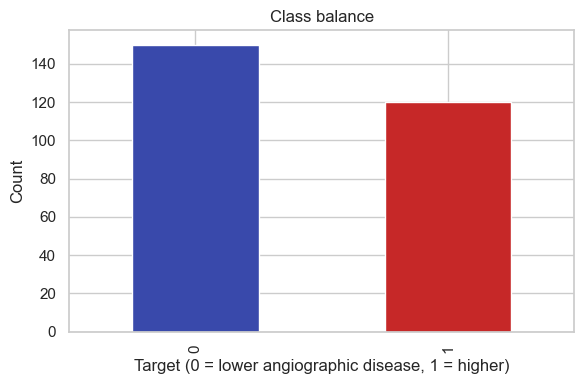

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
df['target'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#3949ab', '#c62828'])
ax.set_xlabel('Target (0 = lower angiographic disease, 1 = higher)')
ax.set_ylabel('Count')
ax.set_title('Class balance')
plt.tight_layout()
plt.show()

## 4. Correlation heatmap (numeric features)

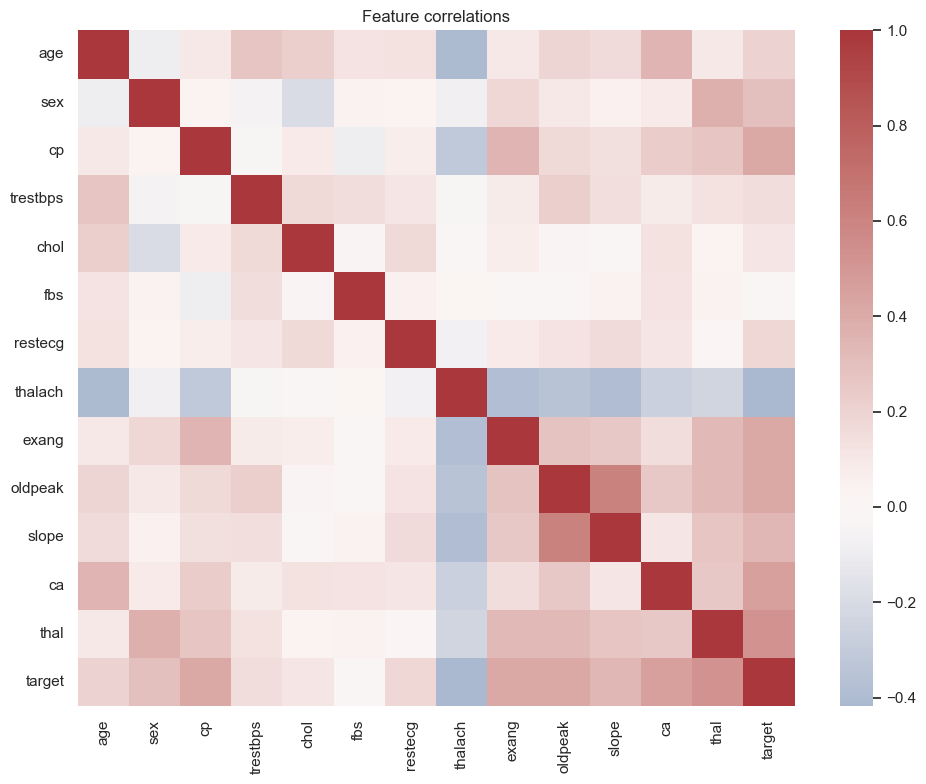

In [4]:
num = df.select_dtypes(include=['number'])
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(num.corr(), cmap='vlag', center=0, ax=ax)
ax.set_title('Feature correlations')
plt.tight_layout()
plt.show()

## 5. Age by target

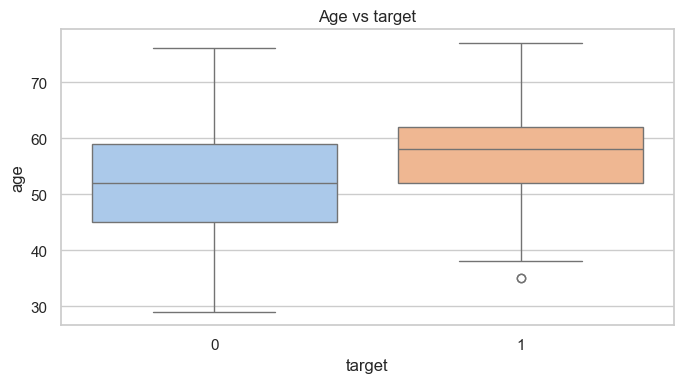

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='target', y='age', palette='pastel', ax=ax)
ax.set_title('Age vs target')
plt.tight_layout()
plt.show()

## 6. Random Forest feature importance

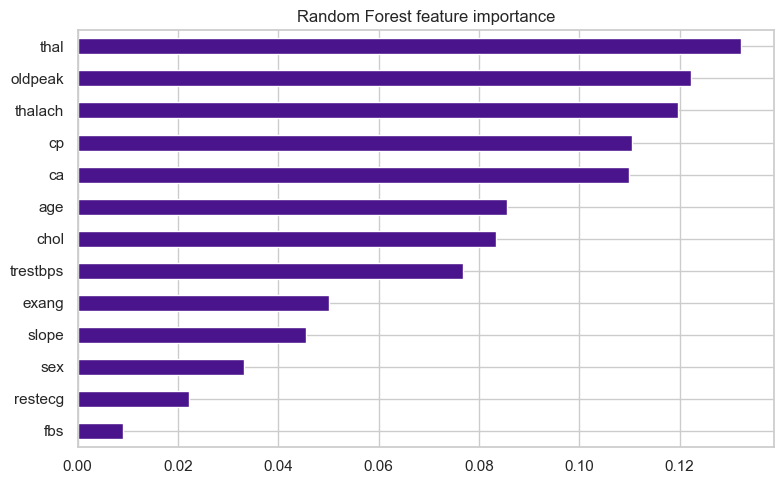

In [6]:
from sklearn.ensemble import RandomForestClassifier
X = df.drop(columns=['target'])
y = df['target']
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind='barh', ax=ax, color='#4a148c')
ax.set_title('Random Forest feature importance')
plt.tight_layout()
plt.show()